#Lijima Shrestha(ACE079BCT035)
# Data Mining Lab Assignment
## Title: Association Analysis on Restaurant Orders Dataset

This report applies association analysis to a restaurant/food-delivery order dataset, compares Apriori and FP-Growth, handles categorical attributes, and examines sequential, subgraph, and infrequent patterns.

## Objectives
- Load and preprocess the restaurant orders dataset.
- Mine frequent itemsets using Apriori and FP-Growth.
- Generate association rules.
- Compare algorithm runtime and results.
- Explore categorical encoding, sequential patterns, subgraph patterns, and infrequent patterns.

In [5]:
import sys
!{sys.executable} -m pip install pandas mlxtend networkx matplotlib scikit-learn --quiet


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
import time
from pathlib import Path
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules
from sklearn.preprocessing import LabelEncoder

DATA_PATH = Path('restaurant_orders.csv')
assert DATA_PATH.exists(), f'Dataset not found: {DATA_PATH}'
df = pd.read_csv(DATA_PATH)
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Product'] = df['Product'].astype('category')
df['transaction_id'] = df['Customer_ID'].astype(str) + '_' + df['Date'].dt.strftime('%Y%m%d')

print('Total rows:', len(df))
print('Unique customers:', df['Customer_ID'].nunique())
print('Unique transactions:', df['transaction_id'].nunique())
print('Unique products:', df['Product'].nunique())
df.head()

Total rows: 370
Unique customers: 35
Unique transactions: 94
Unique products: 23


,Customer_ID,Date,Product,transaction_id
0,1,2025-04-05,burger,1_20250405
1,1,2025-04-05,fries,1_20250405
2,1,2025-04-05,onion_rings,1_20250405
3,1,2025-04-25,burger,1_20250425
4,1,2025-04-25,fries,1_20250425


The dataset has been loaded and preprocessed into transactions by customer and date. This step confirms the dataset size and prepares the data for association mining.

In [7]:
transactions = df.groupby('transaction_id')['Product'].apply(list).tolist()
print('Transactions count:', len(transactions))
print('Example transaction:', transactions[0])

te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
transactions_ohe = pd.DataFrame(te_ary, columns=te.columns_)
print('One-hot encoded transaction shape:', transactions_ohe.shape)
transactions_ohe.iloc[:5, :10]

Transactions count: 94
Example transaction: ['bagel', 'smoothie', 'coffee', 'muffin']
One-hot encoded transaction shape: (94, 23)


,bagel,breadsticks,burger,coffee,dip_sauce,edamame,fries,guacamole,miso_soup,muffin
0,True,False,False,True,False,False,False,False,False,True
1,False,False,False,False,False,False,False,False,False,False
2,False,True,False,False,False,False,False,False,False,False
3,False,True,True,False,False,False,True,False,False,False
4,False,False,False,False,True,False,False,False,False,False


Transactions are encoded as a binary matrix where each column is a menu item and each row is a transaction (one customer's order on one date). This is required for Apriori and FP-Growth mining.

## Frequent Itemset Mining with Apriori
Apriori finds frequent item combinations by pruning candidate itemsets with the Apriori principle.

In [8]:
min_support = 0.03
frequent_itemsets = apriori(transactions_ohe, min_support=min_support, use_colnames=True)
frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(len)
frequent_itemsets.sort_values(['support', 'length'], ascending=[False, False]).head(20)

,support,itemsets,length
16,0.425532,frozenset({smoothie}),1
14,0.414894,frozenset({salad}),1
17,0.340426,frozenset({soda}),1
56,0.276596,"frozenset({smoothie, salad})",2
91,0.265957,"frozenset({smoothie, salad, wrap})",3
59,0.265957,"frozenset({salad, wrap})",2
63,0.265957,"frozenset({smoothie, wrap})",2
22,0.265957,frozenset({wrap}),1
58,0.255319,"frozenset({salad, soup})",2
18,0.255319,frozenset({soup}),1


The Apriori output shows the most frequent itemsets with support above 3%. Higher support indicates menu items that are commonly ordered together within the same transaction. A lower threshold than the groceries example is used here because this dataset has far fewer transactions (94 vs thousands).

In [9]:
rules = association_rules(frequent_itemsets, metric='confidence', min_threshold=0.4)
rules = rules.sort_values(['confidence', 'lift', 'support'], ascending=[False, False, False])
rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(20)

,antecedents,consequents,support,confidence,lift
2,frozenset({muffin}),frozenset({bagel}),0.106383,1.0,9.400000
3,frozenset({bagel}),frozenset({muffin}),0.106383,1.0,9.400000
81,"frozenset({muffin, smoothie})",frozenset({bagel}),0.106383,1.0,9.400000
82,"frozenset({smoothie, bagel})",frozenset({muffin}),0.106383,1.0,9.400000
83,frozenset({muffin}),"frozenset({smoothie, bagel})",0.106383,1.0,9.400000
84,frozenset({bagel}),"frozenset({muffin, smoothie})",0.106383,1.0,9.400000
70,"frozenset({muffin, coffee})",frozenset({bagel}),0.095745,1.0,9.400000
71,"frozenset({bagel, coffee})",frozenset({muffin}),0.095745,1.0,9.400000
76,"frozenset({smoothie, coffee})",frozenset({bagel}),0.095745,1.0,9.400000
116,"frozenset({smoothie, coffee})",frozenset({muffin}),0.095745,1.0,9.400000


Association rules show menu-item pairs and how strongly they are linked. Confidence measures the likelihood of the consequent given the antecedent, and lift indicates rule strength relative to random chance (e.g. a salad order implying a smoothie order).

## Custom Apriori Implementation
This custom version demonstrates the candidate generation and pruning process used by the Apriori principle.

In [10]:
from itertools import combinations

def generate_candidates(prev_level, k):
    candidates = set()
    prev_list = list(prev_level)
    for i in range(len(prev_list)):
        for j in range(i + 1, len(prev_list)):
            union = prev_list[i] | prev_list[j]
            if len(union) == k:
                candidates.add(frozenset(union))
    return candidates

def apriori_custom(transactions, min_support):
    transaction_list = [set(t) for t in transactions]
    transaction_count = len(transaction_list)
    min_count = int(np.ceil(min_support * transaction_count))

    item_counts = {}
    for transaction in transaction_list:
        for item in transaction:
            item_counts[item] = item_counts.get(item, 0) + 1

    level = {frozenset([item]) for item, count in item_counts.items() if count >= min_count}
    support_data = {frozenset([item]): item_counts[item] / transaction_count for item in item_counts if item_counts[item] >= min_count}

    k = 2
    while level:
        candidates = generate_candidates(level, k)
        next_level = set()
        candidate_counts = {candidate: 0 for candidate in candidates}
        for transaction in transaction_list:
            for candidate in candidates:
                if candidate.issubset(transaction):
                    candidate_counts[candidate] += 1
        for candidate, count in candidate_counts.items():
            if count >= min_count:
                next_level.add(candidate)
                support_data[candidate] = count / transaction_count
        level = next_level
        k += 1
    return support_data

custom_supports = apriori_custom(transactions, min_support=min_support)
custom_df = pd.DataFrame([{'itemset': tuple(sorted(itemset)), 'support': support} for itemset, support in custom_supports.items()])
custom_df = custom_df.sort_values(['support', 'itemset'], ascending=[False, True]).reset_index(drop=True)
custom_df.head(15)

,itemset,support
0,"(smoothie,)",0.425532
1,"(salad,)",0.414894
2,"(soda,)",0.340426
3,"(salad, smoothie)",0.276596
4,"(salad, smoothie, wrap)",0.265957
5,"(salad, wrap)",0.265957
6,"(smoothie, wrap)",0.265957
7,"(wrap,)",0.265957
8,"(salad, soup)",0.255319
9,"(soup,)",0.255319


The custom Apriori result verifies that the frequent itemsets and support values align with the library implementation.

## FP-Growth and Algorithm Comparison
FP-Growth uses an FP-tree to mine frequent itemsets without generating all candidate combinations explicitly.

In [11]:
start = time.perf_counter()
fp_itemsets = fpgrowth(transactions_ohe, min_support=min_support, use_colnames=True)
fp_duration = time.perf_counter() - start
fp_itemsets['length'] = fp_itemsets['itemsets'].apply(len)
print('FP-Growth mined itemsets:', len(fp_itemsets))
print(f'FP-Growth runtime: {fp_duration:.5f} seconds')
fp_itemsets.sort_values(['support', 'length'], ascending=[False, False]).head(20)

FP-Growth mined itemsets: 101
FP-Growth runtime: 0.00695 seconds


,support,itemsets,length
0,0.425532,frozenset({smoothie}),1
4,0.414894,frozenset({salad}),1
7,0.340426,frozenset({soda}),1
34,0.276596,"frozenset({smoothie, salad})",2
37,0.265957,"frozenset({smoothie, salad, wrap})",3
35,0.265957,"frozenset({salad, wrap})",2
36,0.265957,"frozenset({smoothie, wrap})",2
5,0.265957,frozenset({wrap}),1
38,0.255319,"frozenset({salad, soup})",2
6,0.255319,frozenset({soup}),1


Apriori mined itemsets: 101
Apriori runtime: 0.00940 seconds


,algorithm,runtime_seconds,itemset_count
0,Apriori,0.009402,101
1,FP-Growth,0.006951,101


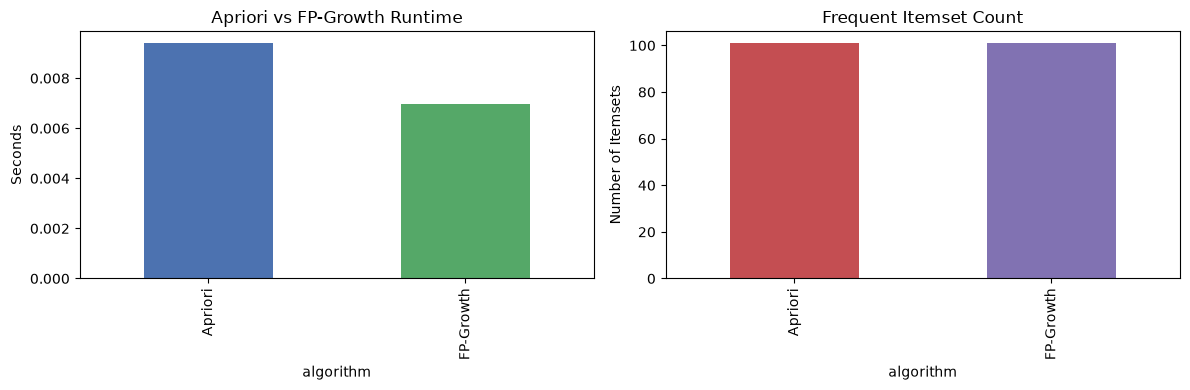

In [12]:
start = time.perf_counter()
apriori_itemsets = apriori(transactions_ohe, min_support=min_support, use_colnames=True)
apriori_duration = time.perf_counter() - start
print('Apriori mined itemsets:', len(apriori_itemsets))
print(f'Apriori runtime: {apriori_duration:.5f} seconds')
comparison = pd.DataFrame({
    'algorithm': ['Apriori', 'FP-Growth'],
    'runtime_seconds': [apriori_duration, fp_duration],
    'itemset_count': [len(apriori_itemsets), len(fp_itemsets)]
})
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
comparison.plot.bar(x='algorithm', y='runtime_seconds', ax=axes[0], legend=False, color=['#4c72b0', '#55a868'])
axes[0].set_title('Apriori vs FP-Growth Runtime')
axes[0].set_ylabel('Seconds')
comparison.plot.bar(x='algorithm', y='itemset_count', ax=axes[1], legend=False, color=['#c44e52', '#8172b2'])
axes[1].set_title('Frequent Itemset Count')
axes[1].set_ylabel('Number of Itemsets')
plt.tight_layout()
comparison

The graph compares Apriori and FP-Growth on runtime and number of frequent itemsets found. This helps evaluate efficiency and output size. On a small dataset like this the runtime difference is negligible, but FP-Growth avoids explicit candidate generation which matters more as data grows.

## Handling Categorical Attributes
Categorical encoding maps menu item names into numerical codes for analysis and preserves category information.

In [13]:
df['product_code'] = LabelEncoder().fit_transform(df['Product'])
encoded_sample = df[['Product', 'product_code']].drop_duplicates().sort_values('product_code').head(20)
print(encoded_sample.to_string(index=False))
category_summary = df['Product'].value_counts().rename_axis('item').reset_index(name='frequency')
category_summary.head(10)

    Product  product_code
      bagel             0
breadsticks             1
     burger             2
     coffee             3
  dip_sauce             4
    edamame             5
      fries             6
  guacamole             7
  miso_soup             8
     muffin             9
     nachos            10
onion_rings            11
      pizza            12
  rice_bowl            13
      salad            14
      salsa            15
   smoothie            16
       soda            17
       soup            18
      sushi            19


,item,frequency
0,smoothie,40
1,salad,39
2,soda,32
3,wrap,25
4,soup,24
5,miso_soup,16
6,breadsticks,15
7,fries,15
8,pizza,15
9,rice_bowl,15


Label encoding assigns each menu item a unique integer. The frequency summary shows the most commonly ordered items, which is useful for categorical attribute analysis.

## Sequential Pattern Mining
Sequential mining identifies item order patterns within a customer's ordered transaction history.

In [14]:
customer_sequences = []
for customer, group in df.groupby('Customer_ID'):
    ordered = group.sort_values('Date').groupby('transaction_id')['Product'].apply(lambda items: tuple(sorted(set(items))))
    if len(ordered) > 0:
        customer_sequences.append(list(ordered))

print('Customer sequences count:', len(customer_sequences))
print('First customer sequence sample:', customer_sequences[0][:5])

Customer sequences count: 35
First customer sequence sample: [('breadsticks', 'pizza', 'salad', 'soda'), ('burger', 'onion_rings', 'soda'), ('burger', 'fries', 'onion_rings'), ('burger', 'coffee', 'fries', 'onion_rings')]


In [15]:
from collections import defaultdict

def mine_sequential_patterns(sequences, min_support):
    sequence_support = defaultdict(int)
    n_sequences = len(sequences)

    for seq in sequences:
        seen_single = set()
        for itemset in seq:
            for item in itemset:
                seen_single.add(item)
        for item in seen_single:
            sequence_support[(item,)] += 1
        for i, itemset_i in enumerate(seq):
            later_items = set().union(*seq[i + 1:]) if i + 1 < len(seq) else set()
            for item_i in itemset_i:
                for item_j in later_items:
                    if item_j != item_i:
                        sequence_support[(item_i, item_j)] += 1

    min_count = int(np.ceil(min_support * n_sequences))
    patterns = [({'sequence': pattern, 'support': count / n_sequences}) for pattern, count in sequence_support.items() if count >= min_count]
    return pd.DataFrame(patterns).sort_values('support', ascending=False)

seq_patterns = mine_sequential_patterns(customer_sequences, min_support=0.2)
seq_patterns.head(20)

,sequence,support
1,"(salad,)",0.600000
13,"(smoothie,)",0.600000
0,"(soda,)",0.571429
20,"(smoothie, salad)",0.514286
16,"(salad, smoothie)",0.457143
21,"(smoothie, wrap)",0.457143
12,"(soup,)",0.428571
17,"(salad, wrap)",0.428571
14,"(wrap,)",0.428571
15,"(salad, soup)",0.400000


The sequential pattern summary lists item follow-on patterns that appear in at least 20% of customers' sequences (a higher threshold than the groceries example since this dataset only has 35 customers). This highlights common ordering relationships, such as customers ordering a salad before later ordering a smoothie.

## Subgraph Pattern Mining
We analyze co-occurrence as a graph and identify strong item pair and triangle motifs.

In [16]:
from itertools import combinations

G = nx.Graph()
for items in transactions:
    unique_items = sorted(set(items))
    for u, v in combinations(unique_items, 2):
        if G.has_edge(u, v):
            G[u][v]['weight'] += 1
        else:
            G.add_edge(u, v, weight=1)

edge_weights = sorted(((u, v, data['weight']) for u, v, data in G.edges(data=True)), key=lambda x: x[2], reverse=True)
print('Top co-occurring menu item pairs:')
for u, v, weight in edge_weights[:15]:
    print(f'{u} - {v}: {weight}')

triangles = []
for clique in nx.enumerate_all_cliques(G):
    if len(clique) == 3:
        weights = [G[u][v]['weight'] for u, v in combinations(clique, 2)]
        triangles.append((tuple(sorted(clique)), min(weights)))

triangles = sorted(triangles, key=lambda x: x[1], reverse=True)
print('Top frequent triangles (subgraphs):')
for clique, weight in triangles[:15]:
    print(f'{clique}: {weight}')

Top co-occurring menu item pairs:
smoothie - salad: 26
smoothie - wrap: 25
salad - wrap: 25
salad - soup: 24
smoothie - soup: 23
soup - wrap: 22
breadsticks - soda: 15
salad - soda: 14
breadsticks - pizza: 14
pizza - soda: 14
miso_soup - edamame: 14
salad - pizza: 13
miso_soup - rice_bowl: 13
edamame - rice_bowl: 13
salad - breadsticks: 12
Top frequent triangles (subgraphs):
('salad', 'smoothie', 'wrap'): 25
('salad', 'smoothie', 'soup'): 23
('smoothie', 'soup', 'wrap'): 22
('salad', 'soup', 'wrap'): 22
('breadsticks', 'pizza', 'soda'): 14
('pizza', 'salad', 'soda'): 13
('edamame', 'miso_soup', 'rice_bowl'): 13
('breadsticks', 'pizza', 'salad'): 12
('breadsticks', 'salad', 'soda'): 12
('edamame', 'miso_soup', 'sushi'): 11
('bagel', 'muffin', 'smoothie'): 10
('guacamole', 'nachos', 'tacos'): 10
('miso_soup', 'rice_bowl', 'sushi'): 10
('edamame', 'rice_bowl', 'sushi'): 10
('bagel', 'coffee', 'muffin'): 9


The co-occurrence graph identifies menu-item pairs and triangles that frequently appear together, illustrating subgraph pattern structure in restaurant orders (for example, salad, smoothie, and wrap forming a common healthy-order bundle).

## Infrequent Pattern Analysis
Rare patterns are identified by examining items and itemsets below a chosen support threshold.

In [17]:
support_threshold = 0.05
item_support = transactions_ohe.mean().sort_values()
infrequent_items = item_support[item_support < support_threshold]
print('Infrequent items below 5% support:', len(infrequent_items))
infrequent_items.head(30)

Infrequent items below 5% support: 0


Series([], dtype: float64)

Infrequent items are those ordered in fewer than 5% of transactions. These rare menu items may be less useful for general association rules but important for niche analysis (e.g. identifying underperforming menu items).

## Conclusion
This lab demonstrates that both Apriori and FP-Growth effectively discover frequent itemsets from the restaurant orders dataset, with FP-Growth typically offering better runtime performance as data scales. The custom Apriori implementation reinforces the underlying candidate pruning logic, while categorical encoding and one-hot transaction representation show how menu item names can be prepared for mining. Sequential pattern mining highlights ordering relationships across customer orders, and subgraph analysis reveals strong co-occurrence item groups (such as salads, smoothies, and wraps). Finally, infrequent pattern analysis identifies items with low support that are useful for niche insights, making the workflow a comprehensive exploration of association, sequential, and graph-based pattern mining applied to restaurant order data.